In [ ]:
!uv pip install -q wordcloud emoji #quiet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #correlation plot
import numpy as np
import emoji
from wordcloud import WordCloud, STOPWORDS
import re #regular expression
import nltk #natural language toolkit

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
# this is a sky
# ['this','is','a','sky']
nltk.download('punkt_tab')
nltk.download('wordnet') # lemmatizer
#porter stemmer--- stemming
from nltk.corpus import stopwords #corpora

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
# this is a sky
# ['this','is','a','sky']

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
combined_df=pd.read_csv("/content/TweetsElonMusk.csv")

In [ ]:
combined_df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1381273474400800773,1381002894032347138,2021-04-11 18:50:33 EEST,2021-04-11,18:50:33,300,44196397,elonmusk,Elon Musk,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'vincent13031925', 'name': 'V...",NaN,NaN,NaN,NaN
1,1381273076709478403,1372444955050971142,2021-04-11 18:48:58 EEST,2021-04-11,18:48:58,300,44196397,elonmusk,Elon Musk,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1381258144916008964,1381230136918433792,2021-04-11 17:49:38 EEST,2021-04-11,17:49:38,300,44196397,elonmusk,Elon Musk,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'agnostoxxx', 'name': 'Shrubb...",NaN,NaN,NaN,NaN
3,1381221447322935303,1381221447322935303,2021-04-11 15:23:49 EEST,2021-04-11,15:23:49,300,44196397,elonmusk,Elon Musk,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1381129584435818496,1381079981485252611,2021-04-11 09:18:47 EEST,2021-04-11,09:18:47,300,44196397,elonmusk,Elon Musk,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'itsALLrisky', 'name': '💸💸💸',...",NaN,NaN,NaN,NaN


In [ ]:
combined_df=combined_df[['created_at','tweet']]
combined_df.head() # display only top 5 rows

,created_at,tweet
0,1.657559e+12,@GailAlfarATX @elonmusk @Tesla @teslacn @Tesla...
1,1.657559e+12,@elonmusk @GailAlfarATX @Tesla @teslacn @Tesla...
2,1.657559e+12,"@elonmusk #Think about buying a country , #Mex..."
3,1.657559e+12,"@get_innocuous Actual receipts, and yet you ha..."
4,1.657559e+12,Tesla wall battery for the save! Power went ou...


In [ ]:
combined_df.shape

(10016, 2)

In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10016 entries, 0 to 10015
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   created_at  10016 non-null  float64
 1   tweet       10016 non-null  object 
dtypes: float64(1), object(1)
memory usage: 156.6+ KB


In [ ]:
# A list of contractions from http://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python
# i don't have car
# i do not have car


# contraction words dont do not
# slang words btw-- by the way

contractions = {"ain't": "am not", "aren't": "are not", "can't": "cannot",
"can't've": "cannot have", "'cause": "because", "could've": "could have",
"couldn't": "could not", "couldn't've": "could not have", "didn't": "did not",
"doesn't": "does not", "don't": "do not", "hadn't": "had not", "hadn't've": "had not have",
"hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'd've": "he would have",
"he'll": "he will", "he's": "he is", "how'd": "how did", "how'll": "how will",
"how's": "how is", "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
"isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is",
"let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have",
"mightn't": "might not", "must've": "must have", "mustn't": "must not",
"needn't": "need not", "oughtn't": "ought not", "shan't": "shall not",
"sha'n't": "shall not", "she'd": "she would", "she'll": "she will", "she's": "she is",
"should've": "should have", "shouldn't": "should not", "that'd": "that would",
"that's": "that is", "there'd": "there had", "there's": "there is", "they'd": "they would",
"they'll": "they will", "they're": "they are", "they've": "they have", "wasn't": "was not",
"we'd": "we would", "we'll": "we will", "we're": "we are", "we've": "we have",
"weren't": "were not", "what'll": "what will", "what're": "what are", "what's": "what is",
"what've": "what have", "where'd": "where did", "where's": "where is", "who'll": "who will",
"who's": "who is", "won't": "will not", "wouldn't": "would not", "you'd": "you would",
"you'll": "you will", "you're": "you are", "wfh": "work from home", "wfo": "work from office",
"idk": "i do not know", "brb": "be right back", "btw": "by the way", "tbh": "to be honest",
"omw": "on my way", "lmk": "let me know", "fyi": "for your information",
"imo": "in my opinion", "smh": "shaking my head", "nvm": "never mind",
"ikr": "i know right", "fr": "for real", "rn": "right now", "gg": "good game",
"dm": "direct message", "afaik": "as far as i know", "bff": "best friends forever",
"ftw": "for the win", "hmu": "hit me up", "ggwp": "good game well played"}


In [ ]:
def clean_text(text, remove_stopwords=True):
    text = text.lower()
    if True:
        #text= "i dont't have supercar"
        text = text.split()
        # ['i','don't','have','supercar']
        new_text = []
        for word in text:
            if word in contractions:
                new_text.append(contractions[word])
                # ['i','do not','have','supercar']
            else:
                new_text.append(word)



        text = " ".join(new_text)
        #[i do not have supercar]

    # Remove URLs
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE) #substitute

    # Remove usernames
    text = re.sub(r'@[A-Za-z0-9]+', '', text)

    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)

    # Remove emojis
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF" \
                               "\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF" \
                               "\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF" \
                               "\U00002702-\U000027B0\U000024C2-\U0001F251]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # Tokenize text
    words = word_tokenize(text)

    # Remove stopwords if needed
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        words = [word for word in words if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)



In [ ]:
combined_df['clean_tweet'] = combined_df['tweet'].apply(lambda x:clean_text(x))

In [ ]:
combined_df.drop_duplicates(inplace=True)

In [ ]:
combined_df.head()

,created_at,tweet,clean_tweet
0,1.657559e+12,@GailAlfarATX @elonmusk @Tesla @teslacn @Tesla...,six 4 still live home homeschooled taught self...
1,1.657559e+12,@elonmusk @GailAlfarATX @Tesla @teslacn @Tesla...,go dozen kids… missing 3 go
2,1.657559e+12,"@elonmusk #Think about buying a country , #Mex...",think buying country mexico could turn richest...
3,1.657559e+12,"@get_innocuous Actual receipts, and yet you ha...",innocuous actual receipt yet ’ asked anyone bu...
4,1.657559e+12,Tesla wall battery for the save! Power went ou...,tesla wall battery save power went still run a...


# Processing the time column

In [ ]:
from datetime import datetime
combined_df['created_at'] = pd.to_datetime(combined_df['created_at'], unit='ms')

In [ ]:
combined_df.head()

,created_at,tweet,clean_tweet
0,2022-07-11 17:06:24,@GailAlfarATX @elonmusk @Tesla @teslacn @Tesla...,six 4 still live home homeschooled taught self...
1,2022-07-11 17:06:21,@elonmusk @GailAlfarATX @Tesla @teslacn @Tesla...,go dozen kids… missing 3 go
2,2022-07-11 17:06:20,"@elonmusk #Think about buying a country , #Mex...",think buying country mexico could turn richest...
3,2022-07-11 17:06:12,"@get_innocuous Actual receipts, and yet you ha...",innocuous actual receipt yet ’ asked anyone bu...
4,2022-07-11 17:06:09,Tesla wall battery for the save! Power went ou...,tesla wall battery save power went still run a...


# Exploratory data analysis

In [ ]:
combined_df["Tweets_length"]= combined_df["clean_tweet"].str.len()

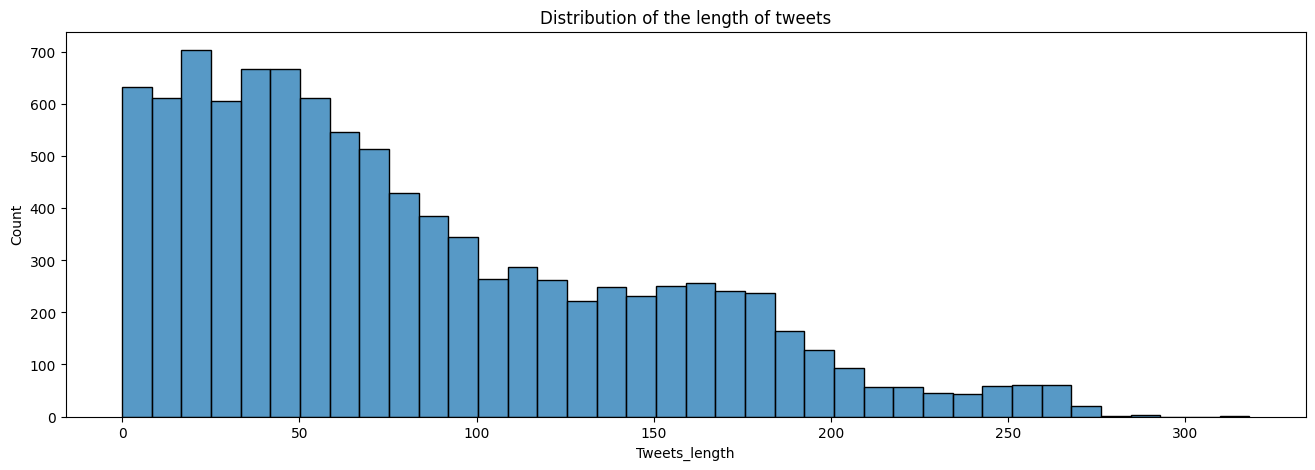

In [ ]:
plt.figure(figsize=(16,5))
sns.histplot(combined_df['Tweets_length'])
plt.title("Distribution of the length of tweets")
plt.show()

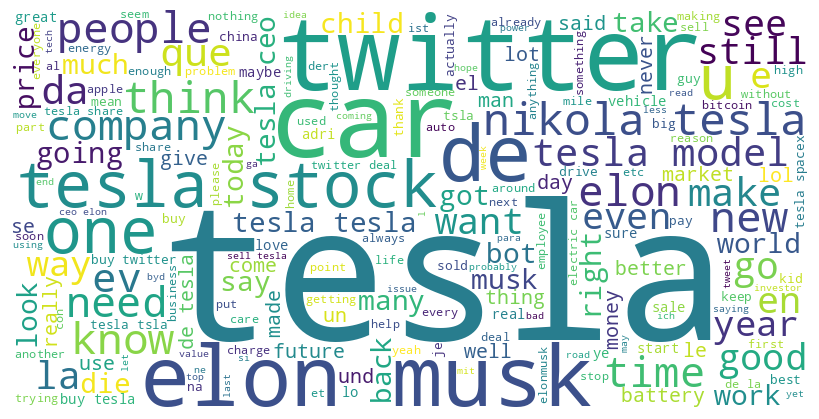

In [ ]:
all_text = ' '.join(combined_df['clean_tweet'])

# Generate word cloud
wordcloud = WordCloud(width = 800, height = 400,
                background_color ='white',
                stopwords = set(STOPWORDS),
                min_font_size = 10).generate(all_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

# Hashtags analysis

In [ ]:
def extract_hashtags(x):
    hashtags = []
    # Loop over the words in the tweet
    for i in x:
        ht = re.findall(r"#(\w+)", i) # \w- [A-Z,a-Z,0-9]
        hashtags.append(ht)
    return hashtags

In [ ]:
hashtags = extract_hashtags(combined_df['tweet'])

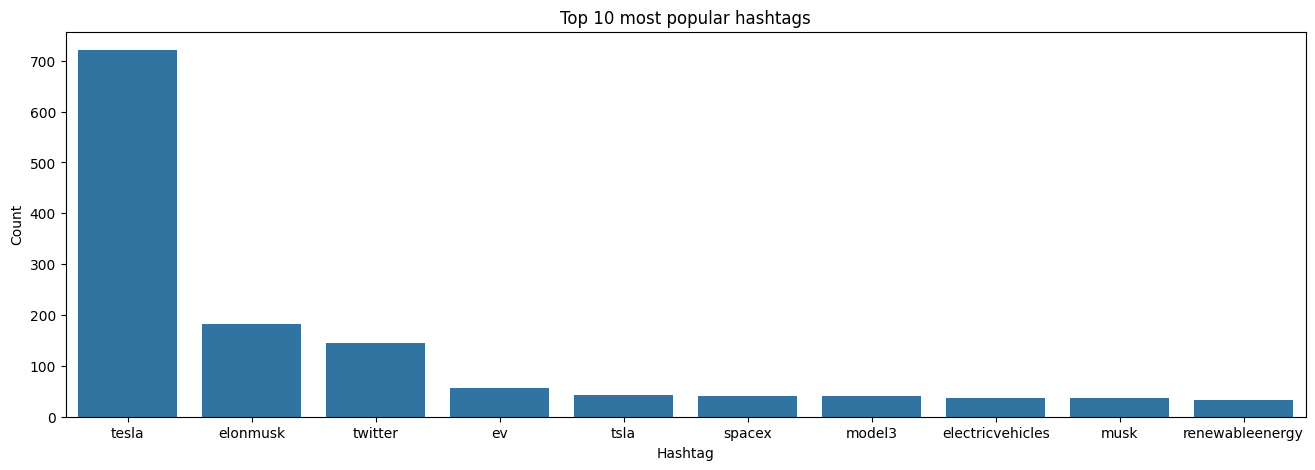

In [ ]:
hashtags_lower = [[tag.lower() for tag in tag_list] for tag_list in hashtags]

combined_hashtags = sum(hashtags_lower, [])

# Compute frequency distribution
freq_dist = nltk.FreqDist(combined_hashtags)
#boy-70, girls-30


# Convert frequency distribution to DataFrame
df_hashtags = pd.DataFrame({'Hashtag': list(freq_dist.keys()), 'Count': list(freq_dist.values())})

df_hashtags['Hashtag'] = df_hashtags['Hashtag'].apply(lambda x: x.lower())
df_hashtags = df_hashtags.groupby('Hashtag', as_index=False)['Count'].sum()

# Select top 10 most frequent hashtags (important fn asked in interview)
top_10_hashtags = df_hashtags.nlargest(columns="Count", n=10) #nsmallest

# Plot the top 10 most popular hashtags
plt.figure(figsize=(16,5))
ax = sns.barplot(data=top_10_hashtags, x="Hashtag", y="Count")
ax.set(ylabel='Count')
plt.title("Top 10 most popular hashtags")
plt.show()


Entity canonicalization

* microsoft
* msft

In [ ]:

'''
canonical_map = {
    'microsoft': ['msft', 'ms', 'windows'],
    'tesla':['tsla','tsla corp']
}

def canonicalize(text):
    text = text.lower()

    for alias, canonical in canonical_map.items():
        pattern = r"\b" + re.escape(alias) + r"\b"
        text = re.sub(pattern, canonical, text, flags=re.IGNORECASE)

    return text

combined_df["canonical_text"] = combined_df["clean_text"].apply(canonicalize)

print(combined_df)
'''

# N Gram Analysis

In [ ]:
from nltk.util import ngrams
from collections import Counter

# boy-40, girl-60

words = all_text.split()
bigram_freq = Counter(ngrams(words, 2))
# boy-40, girl-60

bigram_freq_df = pd.DataFrame(list(bigram_freq.items()), columns=['Bigram', 'Frequency'])
bigram_freq_df = bigram_freq_df.sort_values(by='Frequency', ascending=False)

# Display the top N most frequent bigrams
top_N = 20
print(bigram_freq_df.head(top_N))

               Bigram  Frequency
268      (elon, musk)        582
344    (tesla, stock)        378
2978  (nikola, tesla)        319
82     (tesla, model)        241
216        (tesla, ’)        223
490        (model, 3)        168
842      (tesla, ceo)        149
1652   (tesla, tesla)        148
1183      (de, tesla)        133
54       (buy, tesla)        116
1747   (buy, twitter)        107
461   (tesla, spacex)        103
2323    (tesla, tsla)         94
4110  (twitter, deal)         93
899    (tesla, share)         91
472   (electric, car)         87
636          (de, la)         86
551      (tesla, car)         85
877     (like, tesla)         77
1700    (44, billion)         71


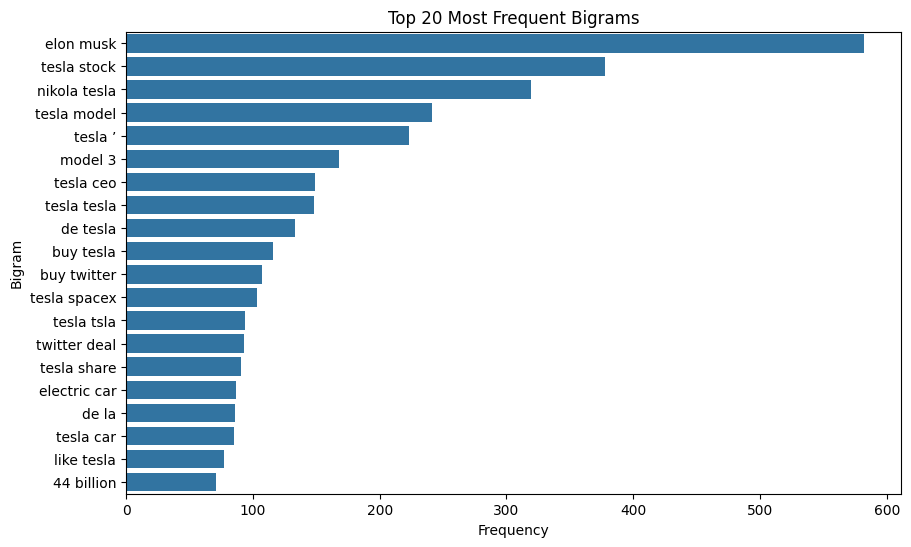

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y=[' '.join(bigram) for bigram in bigram_freq_df['Bigram'].head(top_N)],
            data=bigram_freq_df.head(top_N))
plt.title(f'Top {top_N} Most Frequent Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

In [ ]:
trigram_freq = Counter(ngrams(words, 3))
trigram_freq_df = pd.DataFrame(list(trigram_freq.items()), columns=['Trigram', 'Frequency'])
trigram_freq_df = trigram_freq_df.sort_values(by='Frequency', ascending=False)

top_N = 20


print(trigram_freq_df.head(top_N))


                                Trigram  Frequency
501                   (tesla, model, 3)        112
868                   (ceo, elon, musk)         65
867                  (tesla, ceo, elon)         55
1714                (tesla, elon, musk)         43
2813            (billion, tesla, stock)         43
8844                (elon, musk, tesla)         38
17016              (sell, tesla, stock)         34
8068                    (elon, musk, ’)         34
4710                    (8, 5, billion)         33
4709                       (sell, 8, 5)         31
8233                (5, billion, tesla)         31
24511               (44, billion, deal)         29
4708                   (cover, sell, 8)         28
4176              (macht, zwei, wochen)         27
4177   (zwei, wochen, produktionspause)         27
6784                 (musk, tesla, ceo)         26
271               (elon, musk, twitter)         25
4706               (saga, could, cover)         25
4707               (could, cove

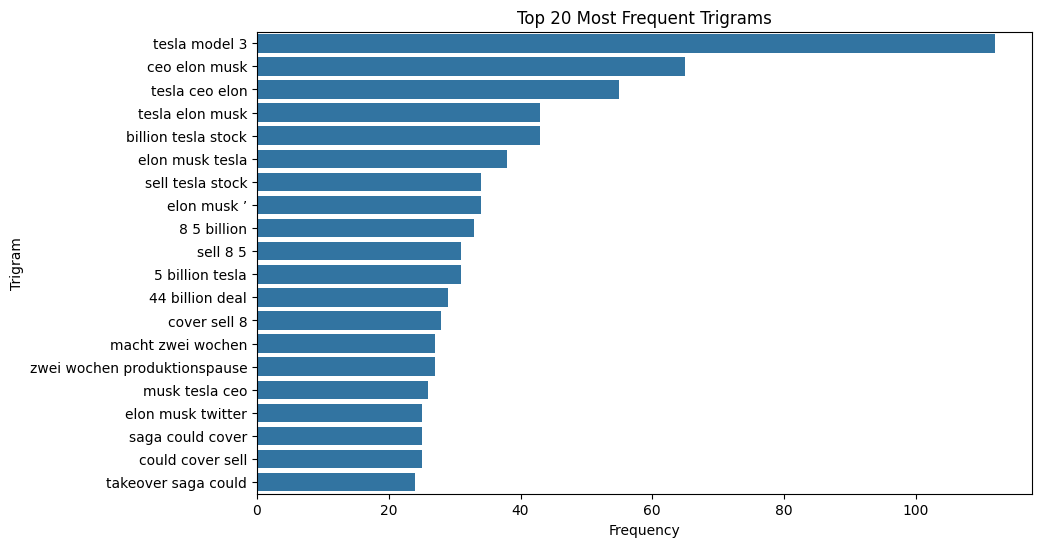

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y=[' '.join(trigram) for trigram in trigram_freq_df['Trigram'].head(top_N)],
            data=trigram_freq_df.head(top_N))
plt.title(f'Top {top_N} Most Frequent Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.show()



# Topic Modelling *** (parameters in topic modelling)

* 1️⃣ max_df=0.95- Removes very frequent words that appear in more than 95% of the documents.
* 2️⃣ min_df=2- Removes rare words that appear in less than 2 documents.
* 3️⃣ stop_words='english'- Removes common English stopwords like "the", "is", "and", "in", etc.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# two document--- each word have 1 unique no---- then we have done the one hot encoding

from sklearn.decomposition import LatentDirichletAllocation #lda

# Tokenize and vectorize the text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(combined_df['clean_tweet'])

lda_model = LatentDirichletAllocation(n_components=5, random_state=42) # Topic modelling
lda_output = lda_model.fit_transform(X)
# random_state=42-- it is used for freezing the result

In [ ]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

# Display the topics
print("Topics found via LDA:")
no_top_words = 10
display_topics(lda_model, vectorizer.get_feature_names_out(), no_top_words)


Topics found via LDA:
Topic 1:
tesla car na je da driving speed like model road
Topic 2:
tesla twitter elon musk deal ceo stock billion child buy
Topic 3:
tesla car like stock company people buy think year ev
Topic 4:
tesla die musk twitter der und da ist elon tsla
Topic 5:
tesla la que en nikola el model le se los


# Sentiment Analysis

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

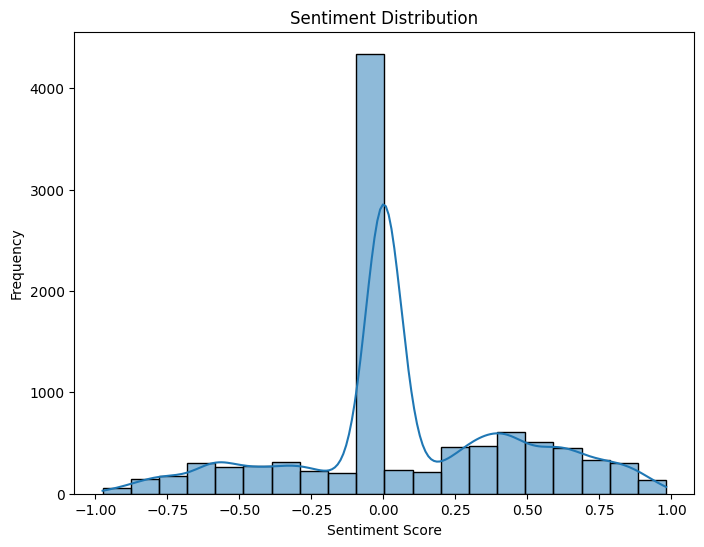

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer() #vader-sentiment-analyzer

# Compute sentiment scores for each tweet
combined_df['sentiment'] = combined_df['clean_tweet'].apply(lambda x: sia.polarity_scores(x)['compound'])

# high positive
# moderate postive
# sligthly positve
# neutral
# high negative
# moderate negative
# sligthly negative


# Plot sentiment distribution
plt.figure(figsize=(8, 6))
sns.histplot(combined_df['sentiment'], bins=20, kde=True)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

# Tf-IDF vectorizer

* tell us which words are most important in a document or row

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
# max-   maximum no of document a term can appear
# min-   minimum no of document a term can appear


'''
min_df: This parameter specifies the minimum number of documents a term must appear in to be included in the TF-IDF matrix.
 Terms that appear in fewer documents than min_df will be ignored.
 Setting min_df to a higher value can help filter out noise or very rare terms.

max_df: This parameter specifies the maximum number of documents a term can appear in to be included in the TF-IDF matrix.
 Terms that appear in more documents than max_df will be ignored.
  Setting max_df to a lower value can help filter out very common terms or stop words that might not carry much meaningful information.

'''
# idf----- total no of documents / frequency of each work
# tfidf----tf* log(idf)


# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(combined_df['clean_tweet'])

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get top keywords for each tweet
top_keywords = []
for i in range(len(combined_df)):
    feature_index = tfidf_matrix[i,:].nonzero()[1]
    tfidf_scores = zip(feature_index, [tfidf_matrix[i, x] for x in feature_index])
    top_keywords.append(sorted([(feature_names[i], s) for (i, s) in tfidf_scores], key=lambda x: x[1], reverse=True)[:5])

# Display top keywords
combined_df['top_keywords'] = top_keywords
combined_df[['clean_tweet', 'top_keywords']].head(10)


,clean_tweet,top_keywords
0,six 4 still live home homeschooled taught self...,"[(education, 0.5269827668764496), (taught, 0.2..."
1,go dozen kids… missing 3 go,"[(kids, 0.6284890186460601), (dozen, 0.5806875..."
2,think buying country mexico could turn richest...,"[(mexico, 0.4976142122452972), (country, 0.403..."
3,innocuous actual receipt yet ’ asked anyone bu...,"[(receipt, 0.35322210659126224), (grifter, 0.3..."
4,tesla wall battery save power went still run a...,"[(wall, 0.4101832580652704), (ac, 0.3815651696..."
5,sale 2021 used tesla model standard range rear...,"[(nebraska, 0.28794579772630835), (64, 0.27885..."
6,think buying country mexico could turn richest...,"[(mexico, 0.4976142122452972), (country, 0.403..."
7,tsla full macd cross yet remember buy 700 sell...,"[(700, 0.4508093141389165), (weakness, 0.28056..."
8,far remember leonardo da vinci already wrote s...,"[(leonardo, 0.4919914460752215), (love, 0.4455..."
9,let ’ real average american going pay 40k 70k ...,"[(40k, 0.2714968557553249), (brink, 0.27149685..."


# Assignment

Implement for this telugu dataset

https://www.kaggle.com/datasets/sudalairajkumar/telugu-nlp

https://www.kaggle.com/datasets/disisbig/tamil-news-dataset

https://www.kaggle.com/datasets/disisbig/kannada-news-dataset

https://www.kaggle.com/datasets/asmaaabdelwahab/arabic-news-dataset

https://www.kaggle.com/datasets/vigneshvit/hindi-news-category-dataset

In [ ]:
# https://www.kaggle.com/datasets/andradaolteanu/all-elon-musks-tweets?select=TweetsElonMusk.csv